In [1]:
#==========QUÁ TRÌNH EXPLANATORY DATA ANALYSYS============ 
#Đây lá quá trình khai thác thông tin tri thức từ dữ liệu thông qua biểu đồ.  
#Khi vẽ biểu đồ chúng ta cần đặt rá các câu hỏi 
#1. Có bao nhiêu biến tham gia vào biểu đồ 
#2. Loại (định tính, định lượng) của từng biến số 
#3. Biểu đồ biểu diễn bao nhiêu thông tin 
#4. Tri thức gì được rút trích ra từ biểu đồ 
#5. Tri thức được rút trích có liên quan gì đến nghiệp vụ 
#=========================================== 
#Bước 1: Xử lý dữ liệu cơ bản theo yêu cầu 
#=========================================== 
#1.1. Đọc dữ liệu 
#1.2. Loại bỏ dòng dữ liệu trống 
#1.3. Loại bỏ dòng dữ liệu bị trùng 
#1.4. Kiểm tra các dữ liệu thiếu bằng chart 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
#1.1. Đọc dữ liệu 
#df = pd.read_csv('orginal_sales_data_edit.csv') 
df =pd.read_csv('orginal_sales_data_edit.csv',encoding='utf-8', header=0,delimiter=',') 
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [2]:
#1.2. Loai bo dong du lieu trống
df.dropna(inplace=True,how='all')
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [3]:
# 1.3. Loại bỏ dữ liệu trùng, biết rằng dữ liệu trùng là dữ liệu có đồng thời 
# ORDERNUMBER và OrDERDATE như nhau 
#Kiểm tra lại nghiệp vụ này 
df.drop_duplicates(inplace=True) 
df #2824 dòng 
#1.3. Loại bỏ dữ liệu trùng, biết rằng dữ liệu trùng là dữ liệu có đồng thời 
# ORDERNUMBER và OrDERDATE như nhau 
#Kiểm tra lại nghiệp vụ này 
df.drop_duplicates(inplace=True) 
df #2824 dòng 

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


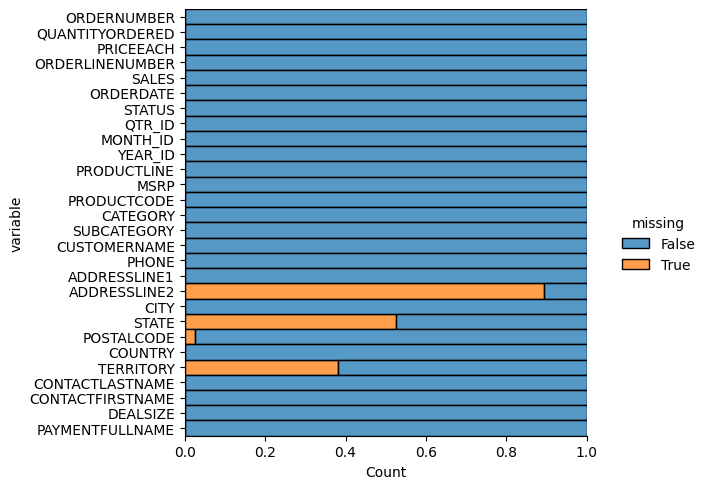

In [4]:

#1.4. Kiểm tra dữ liệu thiếu bằng chart 
# Cách 2: Trực quan dữ liệu thiếu vời Seaborn Displt 
plt.Figure(figsize=(10,6)) 
sns.displot(data=df.isna().melt(value_name="missing"), 
y="variable", 
hue="missing", 
multiple="fill", 
aspect=1.25) 
plt.savefig("my_missing_value_2.png",dpi=100) 

In [5]:
#1.4.1. Điền thiếu dữ liệu với dữ liệu định tính 
#1.4.1.1. Với dữ liệu biểu diễn dạng chuỗi thì thay bằng Unknown 
#1.4.1.2. Với dữ liệu biểu diễn dạng số thì thay bằng 0 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
#1.1. Đọc dữ liệu 
df =pd.read_csv('orginal_sales_data_edit.csv', encoding='UTF8',header=0, delimiter=',')

In [6]:
#1.2. Loại bỏ dòng dữ liệu rỗng 
print("Dữ liệu chưa loại bỏ") 
df.info 
df 
#Dữ liệu sau khi loại bỏ 
print("Dữ liệu sau khi loại bỏ") 
df.dropna(how='all',inplace=True) 
df 

Dữ liệu chưa loại bỏ
Dữ liệu sau khi loại bỏ


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004,Shipped,4,12,2004,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small,Freyre Diego
2819,10373,29,100.00,1,3978.51,1/31/2005,Shipped,1,1,2005,...,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium,Koskitalo Pirkko
2820,10386,43,100.00,4,5417.57,3/1/2005,Resolved,1,3,2005,...,NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre Diego
2821,10397,34,62.24,1,2116.16,3/28/2005,Shipped,1,3,2005,...,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small,Roulet Annette


In [7]:
#1.3. Loại bỏ dữ liệu trùng 
#2823 dòng 
df.drop_duplicates(inplace=True) 
df 
df.drop_duplicates(subset=['ORDERNUMBER','ORDERDATE'],inplace=True) 
df[['ORDERNUMBER','ORDERDATE']]#Kết quả là 2733 

,ORDERNUMBER,ORDERDATE
0,10107,2/24/2003
1,10121,5/7/2003
2,10134,7/1/2003
3,10145,8/25/2003
4,10159,10/10/2003
...,...,...
2358,10199,12/1/2003
2532,10397,3/28/2005
2554,10352,12/3/2004
2692,10118,4/21/2003


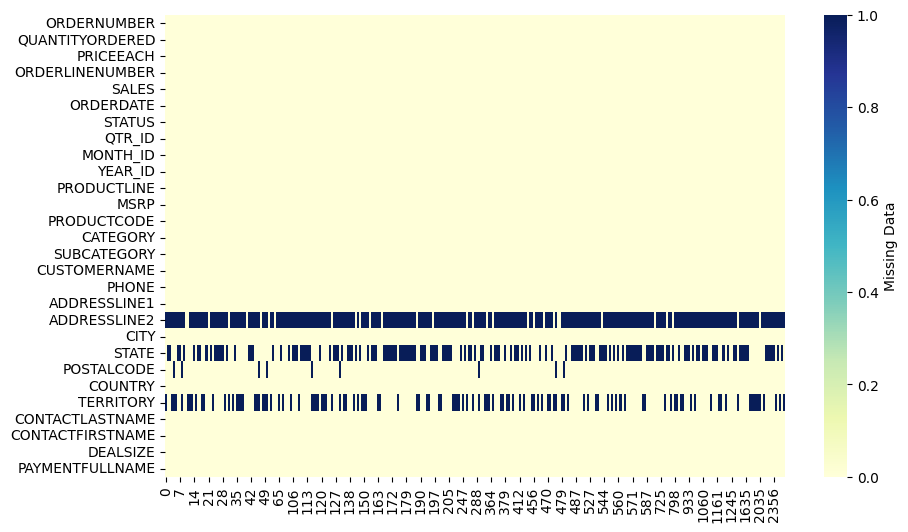

In [8]:
# 1.4. Kiểm tra các dữ liệu thiếu bằng chart 
#Trực quan dữ liệu thiếu với Seaborn HeatMap, cột màu đậm đang bị thiếu dữ liệu 
plt.figure(figsize=(10,6)) 
sns.heatmap(df.isna().transpose(),cmap="YlGnBu",cbar_kws={'label':'Missing Data'}) 
plt.savefig("my_missing_value_1.png",dpi=100) 

<Figure size 1000x600 with 0 Axes>

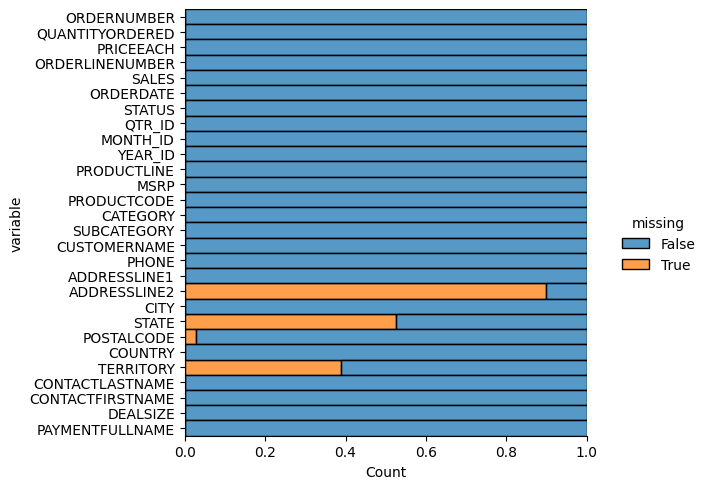

In [9]:
#Cách 2: Trực quan dữ liệu thiếu bằng Seaborn Displot 
plt.figure(figsize=(10,6)) 
sns.displot(data=df.isna().melt(value_name="missing"),y="variable", 
hue="missing",multiple="fill",aspect=1.25) 
plt.savefig("my_missing_value_2.png",dpi=100) 

In [10]:
#1.4.1. Điền thiếu dữ liệu với dữ liệu định tính 
#1.4.1.1. Với dữ liệu biểu diễn dạng chuỗi thì thay dữ liệu thiếu bằng Unknown 
#1.4.1.2. Với dữ liệu biểu diễn dạng số thì thay bằng 0  
df['ADDRESSLINE2'].fillna('Unknown', inplace=True) 
df['STATE'].fillna('Unknow',inplace=True) 
df['TERRITORY'].fillna('Unknown',inplace=True) 
df['POSTALCODE'].fillna(0,inplace=True)
print("Xem lại thông tin") 
df[['ADDRESSLINE2','STATE','TERRITORY','POSTALCODE']] 

Xem lại thông tin


,ADDRESSLINE2,STATE,TERRITORY,POSTALCODE
0,Unknown,NY,Unknown,10022
1,Unknown,Unknow,EMEA,51100
2,Unknown,Unknow,EMEA,75508
3,Unknown,CA,Unknown,90003
4,Unknown,CA,Unknown,0
...,...,...,...,...
2358,Unknown,CA,Unknown,94019
2532,Unknown,Unknow,EMEA,31000
2554,Unknown,MA,Unknown,58339
2692,Unknown,Unknow,EMEA,8022


In [11]:
#1.5. Tách 1 cột thành 2 cột. Sau đó xoá cột bị tách  
df[['PAYMENTLASTNAME', 
'PAYMENTFIRSTNAME']]=df['PAYMENTFULLNAME'].str.split(' ',expand=True) 
df=df.drop('PAYMENTFULLNAME',axis=1) 
df[['PAYMENTLASTNAME', 'PAYMENTFIRSTNAME']] 

,PAYMENTLASTNAME,PAYMENTFIRSTNAME
0,Yu,Kwai
1,Henriot,Paul
2,DaCunha,Daniel
3,Young,Julie
4,Brown,Julie
...,...,...
2358,Thompson,Steve
2532,Roulet,Annette
2554,Taylor,Leslie
2692,Saavedra,Eduardo


In [12]:
#1.6. Lưu dữ liệu thành file mới 
df.to_csv('processed_sales_data.csv',sep=',',encoding='utf-8',index=False) 

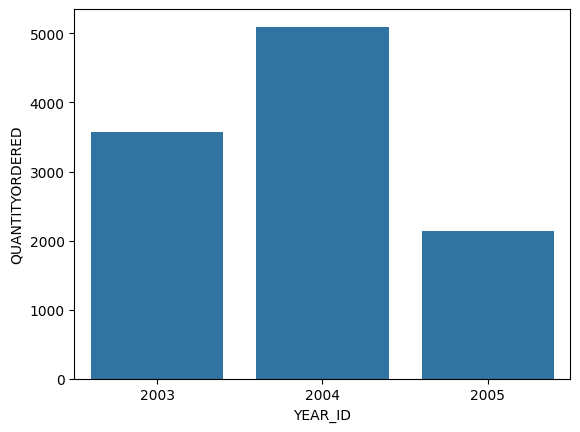

In [13]:
#1.1.1. Cho biết tổng số lượng sản phẩm bán được của mỗi năm 
sns.barplot(x='YEAR_ID', 
            y='QUANTITYORDERED',data=df,errorbar=None,estimator=sum) 
plt.show() 

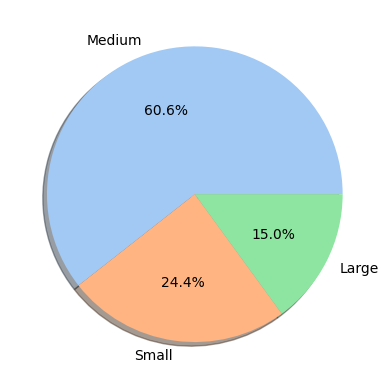

In [14]:
#1.1.2.Có bao nhiêu đơn hàng theo Dealsize 
labels=df['DEALSIZE'].value_counts().index 
values=df['DEALSIZE'].value_counts().values 
colors=sns.color_palette('pastel') 
plt.pie(values,labels=labels, colors=colors, autopct='%1.1f%%', shadow=True) 
plt.show() 

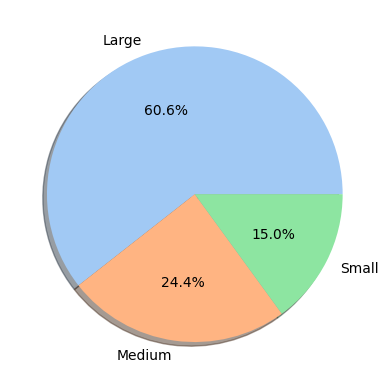

In [15]:
# 1.1.3.HOAc SU DUNG NANG CAO VOI NHIEU TUY CHINH TRONG HAM TONG 
# HOP 
#1.1.3. Cho biết tỉ lệ giá trị SALES theo DEALSIZE 
gb=df.groupby(['DEALSIZE'])['ORDERNUMBER'].agg(['count']) 
data=list(gb['count']) 
labels=gb.index 
colors=sns.color_palette('pastel') 
plt.pie(values,labels=labels, colors=colors, autopct='%1.1f%%', shadow=True) 
plt.show() 

<Axes: xlabel='ORDERDATE', ylabel='SALES'>

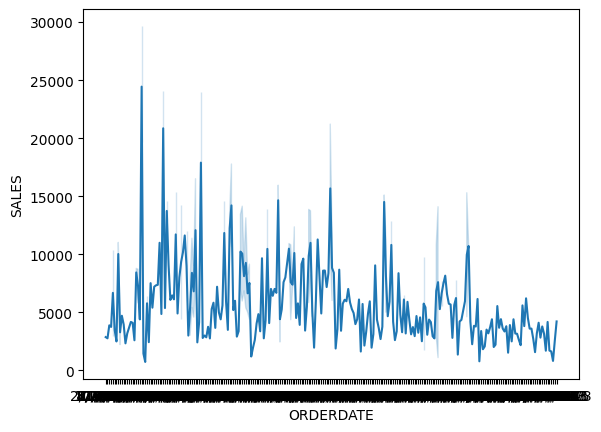

In [16]:
#1.1.7. Cho biết tổng giá trị SALES theo ngày 
sns.lineplot(x="ORDERDATE",y="SALES",data=df, estimator=sum) 

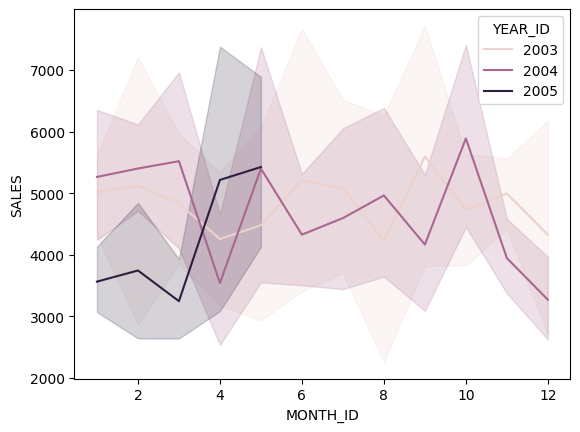

In [17]:
#1.1.8. Cho biết giá trị SALES trung bình theo tháng năm 
#default estimator=mean 
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID',data=df) 
plt.show() 

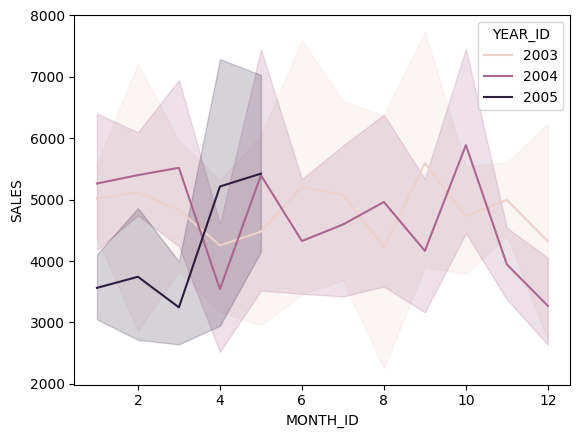

In [18]:
#1.1.8. Cho biết giá trị SALES trung bình theo tháng năm 
#default estimator=mean 
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID',data=df) 
plt.show() 

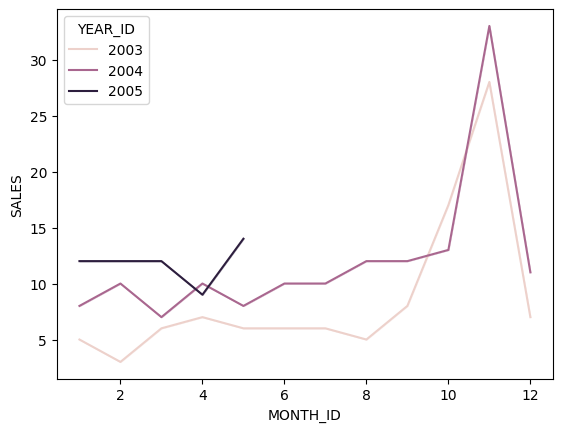

In [19]:
#1.1.8.a Cho biết giá trị SALES theo tháng năm 
from numpy import count_nonzero 
sns.lineplot ( 
x="MONTH_ID",y="SALES",hue='YEAR_ID',data=df,estimator=count_nonzero) 
plt.show() 

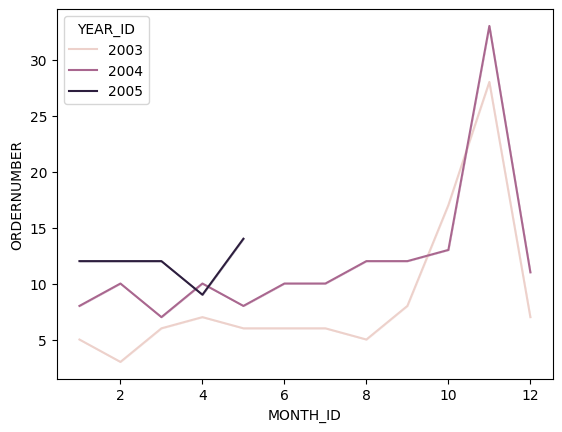

In [20]:
#1.1.9. Cho biết số lượng hoá đơn theo tháng, năm 
#Dùng biểu đồ Line 
from numpy import count_nonzero 
sns.lineplot(x='MONTH_ID',y='ORDERNUMBER',hue='YEAR_ID',data=df,estimator=
 count_nonzero) 
plt.show() 

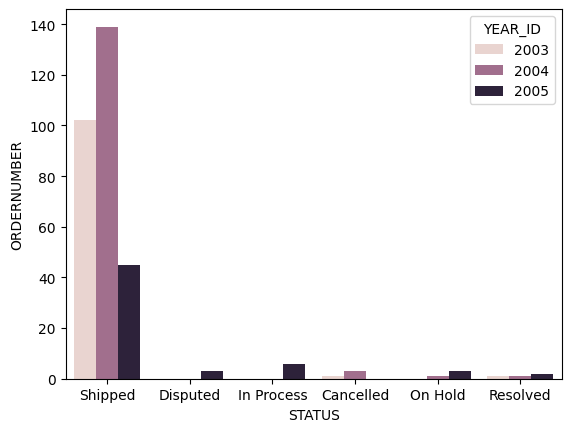

In [21]:
#Cách 2: Dùng barplot 
sns.barplot(x='STATUS', y='ORDERNUMBER',hue='YEAR_ID',data=df, 
            errorbar=None,estimator=count_nonzero) 
plt.show() 

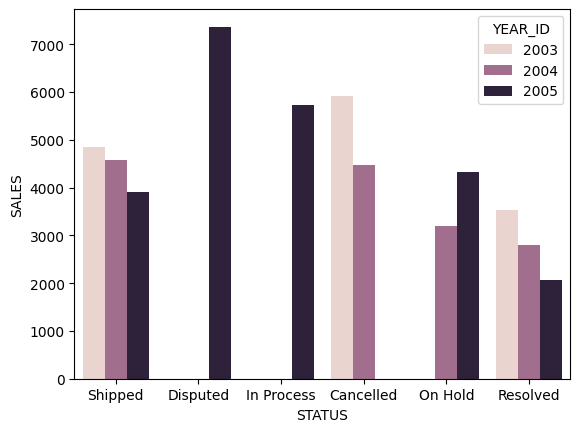

In [22]:
# CHO BIET GIA TRI DON HANG THEO TRANG THAI (STATUS) THEO NHOM 
# CAC NAM(YEAR_ID) 
#Dùng biểu đồ barplot 
sns.barplot(x='STATUS',y='SALES',hue='YEAR_ID',data=df,errorbar=None)
plt.show()

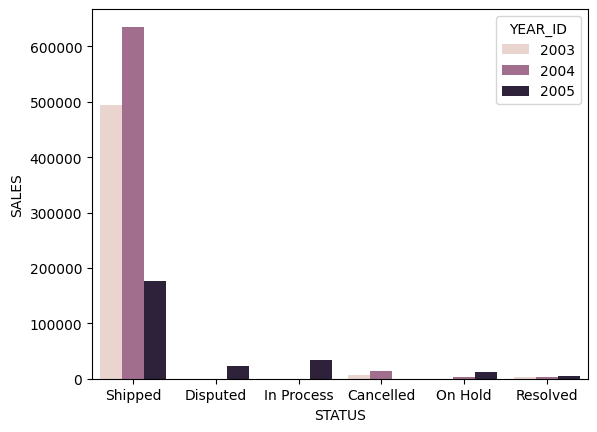

In [24]:
# TONG GIA TRI DON HANG THEO TRANG THAI(STATUS) THEO NHOM CAC 
# NAM (YEAR_ID) 
#1.2.1. Cho biết tổng giá trị đơn hàng theo từng trạng thái (STATUS) của mỗi năm 
sns.barplot(x='STATUS',y='SALES',hue='YEAR_ID',data=df,errorbar=None,estimator=sum) 
plt.show() 

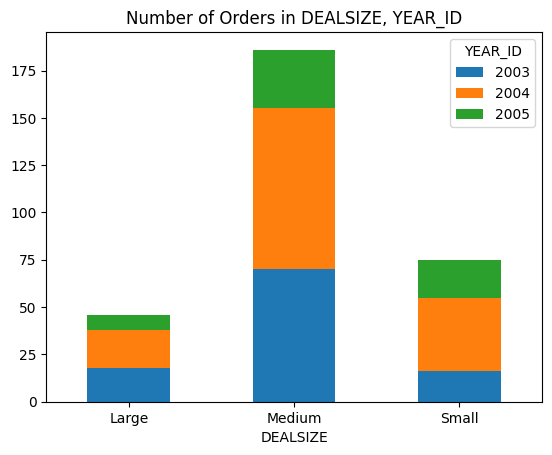

In [25]:
# SO LUONG HOA DON GIUA CAC DEALSIZE THEO YEAR_ID 
#1.2.3. Cho biết số lượng hoá đơn giữa các nhóm DEALSIZE theo từng năm YEAR_ID 
gb=df.groupby(['DEALSIZE','YEAR_ID'])['ORDERNUMBER'].count().unstack() 
gb.plot(kind='bar',stacked=True) 
#just add a title and rotate the x-axis labels to the horizontal 
plt.title('Number of Orders in DEALSIZE, YEAR_ID') 
plt.xticks(rotation=0,ha='center') 
plt.show() 

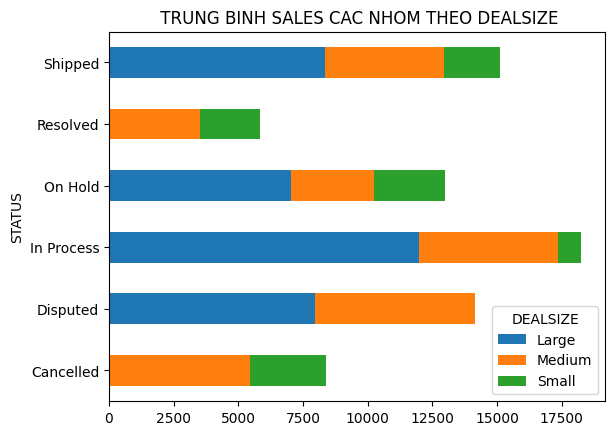

In [26]:
# TRUNG BINH SALES CAC NHO STATUS THEO DEALSIZE 
#1.2.4. Cho biết trung bình SALES theo từng STATUS và DEALSIZE 
gb=df.groupby(['STATUS','DEALSIZE'])['SALES'].mean().unstack() 
gb.plot(kind='barh',stacked=True) 
#just add a title and rotate the x-axis labels to the horizontal 
plt.title(' TRUNG BINH SALES CAC NHOM THEO DEALSIZE') 
plt.xticks(rotation=0,ha='center') 
plt.show() 

In [27]:
# 3. MÔ TẢ DỮ LIỆU 
#3.1. Mô tả dữ liệu cột QuantityOrdered 
df['QUANTITYORDERED'].describe() 

count    307.000000
mean      35.205212
std       10.431550
min        6.000000
25%       27.000000
50%       35.000000
75%       43.000000
max       97.000000
Name: QUANTITYORDERED, dtype: float64

In [28]:
# MO TA DU LIEU CUA QUANTITYORDERED, PRICEEACH, SALES 
#3.2. Mô tả dữ liệu của QUANTITYORDERED, PRICEEACH 
df[['QUANTITYORDERED','PRICEEACH','SALES']].describe() 

,QUANTITYORDERED,PRICEEACH,SALES
count,307.000000,307.000000,307.000000
mean,35.205212,93.351596,4588.486906
std,10.431550,14.912985,2142.986902
min,6.000000,34.910000,553.950000
25%,27.000000,96.915000,3010.500000
50%,35.000000,100.000000,4196.800000
75%,43.000000,100.000000,5855.460000
max,97.000000,100.000000,12001.000000


In [29]:
# MO TA DU LIEU SALES THEO NHOM DEALSIZE 
#Mô tả số lượng bán hàng theo từng DEALSIZE 
df.groupby('DEALSIZE')['QUANTITYORDERED'].describe() 

,count,mean,std,min,25%,50%,75%,max
DEALSIZE,,,,,,,,
Large,46.0,44.739130,11.227812,29.0,38.0,44.0,47.0,97.0
Medium,186.0,35.672043,8.395943,20.0,30.0,36.0,42.0,55.0
Small,75.0,28.200000,9.502489,6.0,22.0,25.0,33.0,49.0


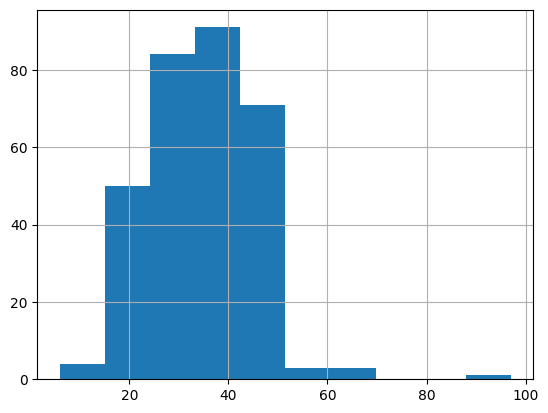

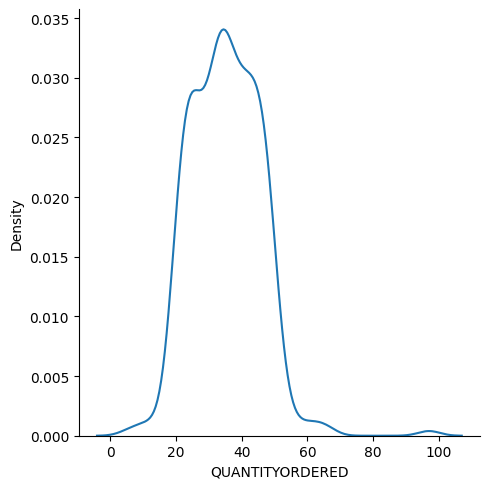

In [31]:
# PHẦN 4: KHAI THÁC SỰ PHÂN PHỐI DỮ LIỆU, CHỈ DÙNG TRÊN BIẾN ĐỊNH 
# LƯỢNG 
#4.1. VE BIEU DO HISTOGRAM CUA QUANTITYORDERED 
df['QUANTITYORDERED'].hist() 
plt.show() 
#HOAC NANG CAO HON VOI NHIEU TUY CHON 
sns.displot(df,x="QUANTITYORDERED",kind="kde") 
plt.show() 

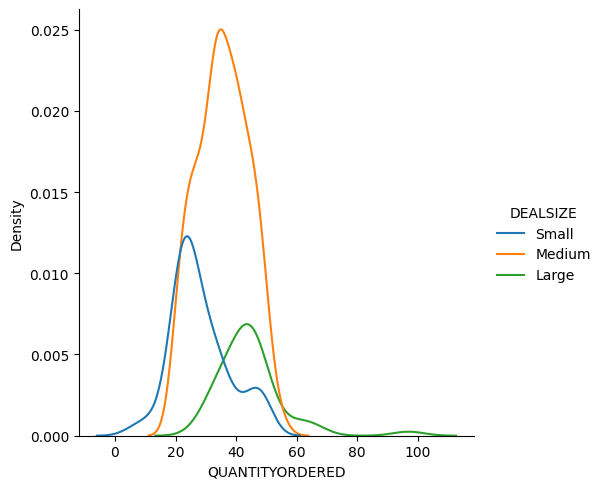

In [32]:
# CHO BIẾT XÁC SUẤT XẢY RA TRÊN MỖI ĐOẠN 
#4.2. VE BIEU DO HIS CUA QUANTITYORDERED THEO DEALISIZE //PHAN 
# PHOI HIS CUA QUANTITYORDERED THEO NHOM DEALSIZE 
#màu xanh lá cây ổn định nhất 
sns.displot(df, x="QUANTITYORDERED",hue="DEALSIZE",kind="kde") 
plt.show() 

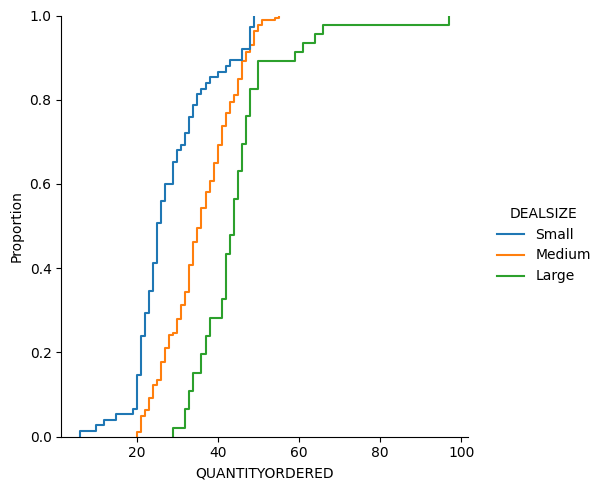

In [33]:
#4.3. VE BIEU DO HIS CUA QUANTITYORDERED THEO DEALISIZE //PHAN 
# PHOI HIS CUA QUANTITYORDERED THEO NHOM DEALSIZE 
sns.displot(df, x="QUANTITYORDERED",hue="DEALSIZE",kind="ecdf") 
plt.show() 

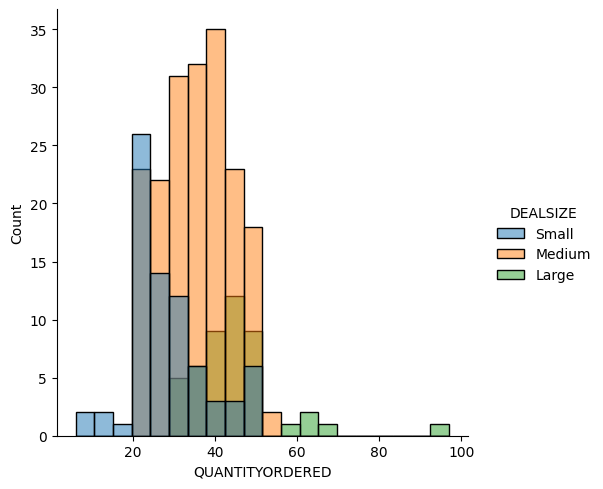

In [34]:
#4.4. VE BIEU DO HIS CUA QUANTITYORDERED THEO DEALISIZE //PHAN 
# PHOI HIS CUA QUANTITYORDERED THEO NHOM DEALSIZE 
sns.displot(df, x="QUANTITYORDERED",hue="DEALSIZE",kind="hist") 
plt.show() 

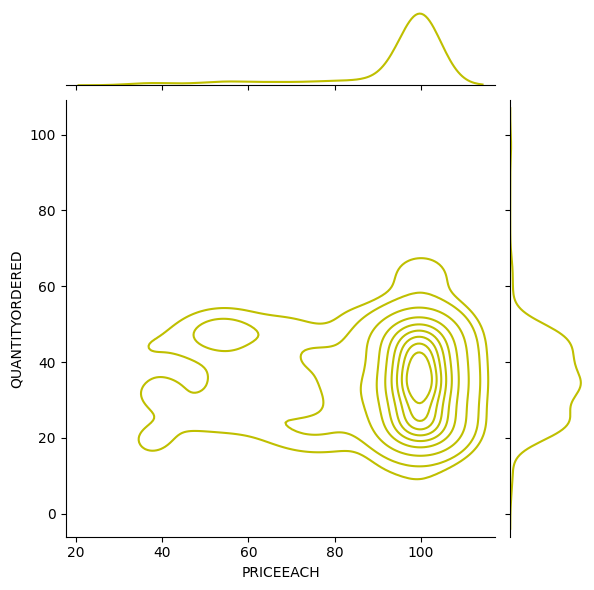

In [35]:
# VE BIEU DO JOINPLOT CUA QUANTITYORDERED VA PRICEEACH 
#4.5. VE BIEU DO JOINPLOT CUA QUANTITYORDERED VA PRICEEACH 
sns.jointplot(data=df,x='PRICEEACH',y='QUANTITYORDERED',kind='kde',color='y')

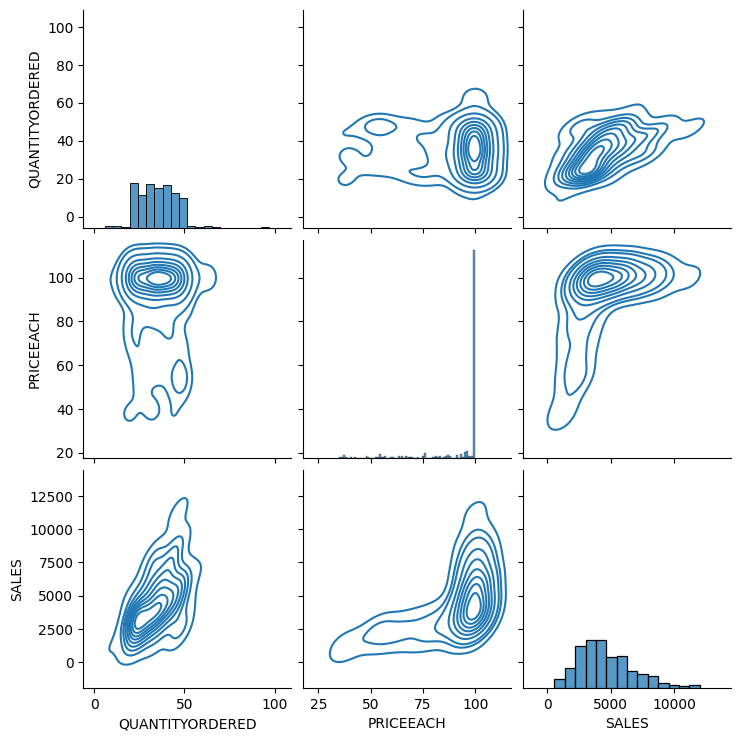

In [36]:
#4.6. VE BIEU DO PAIRPLOT CUA QUANTITYORDERED,PRICEEACH,SALES 
sns.pairplot(df[['QUANTITYORDERED','PRICEEACH','SALES']],diag_kind='hist',kind
 ='kde') 
plt.show() 

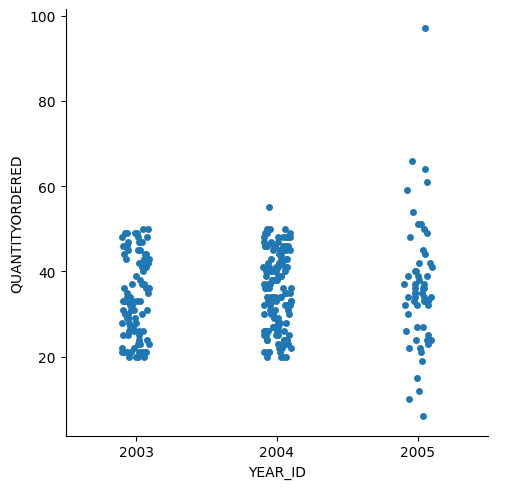

In [37]:
 
# BIỂU DIỄN TƯƠNG QUAN BIẾN SỐ THEO TỪNG CẶP
#4.8. Vẽ trực quan số lượng sản phẩm phân phối theo năm của QuantityOrdered (catplot) 
sns.catplot(x='YEAR_ID',y='QUANTITYORDERED',data=df) 
plt.show() 
# Hỏi câu hỏi: 

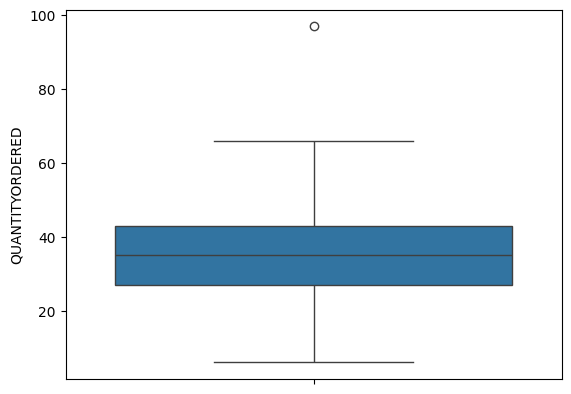

In [39]:
# VE TRUC QUAN SO LUONG SAN PHAM PHAN PHOI THEO NAM CUA 
# QUANTITYORDERED  
#4.9. Vẽ trực quan số lượng sản phẩm phân phối theo năm của cột 
# QUANTITYORDERED 
sns.boxplot(data=df['QUANTITYORDERED']) 
plt.show()

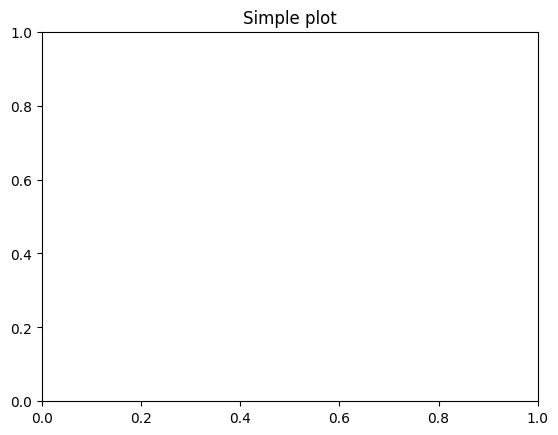

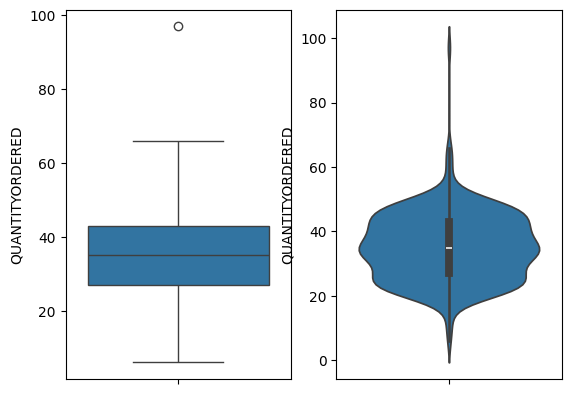

In [45]:
#4.10.1.BIỂU THỊ CHO NGOẠI BIÊN 
#BIEU DIEN (BOXPLOT,VIOLIN) CUA QUANTITYODERED TREN CUNG 
# CHART  
fig, ax = plt.subplots() 
ax.set_title('Simple plot')
ax.set_title('Simple plot') 
#fig, axs = plt.subplots(2, 2, subplot_kw=dict(projection="polar")) 
fig,axes =plt.subplots(1,2) 
sns.boxplot(data=df['QUANTITYORDERED'],ax=axes[0]) 
sns.violinplot(data=df['QUANTITYORDERED'],ax=axes[1]) 
plt.show() 

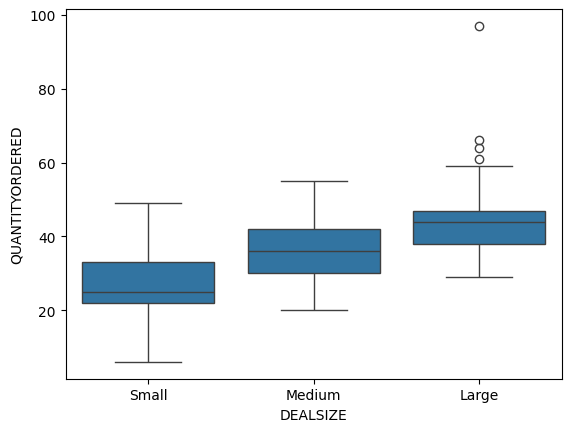

In [46]:
# BIEU DIEN BOXPLOT CUA QUANTITYORDERED THEONHOM DEALSIZE 
sns.boxplot(x='DEALSIZE',y='QUANTITYORDERED',data=df) 
plt.show() 

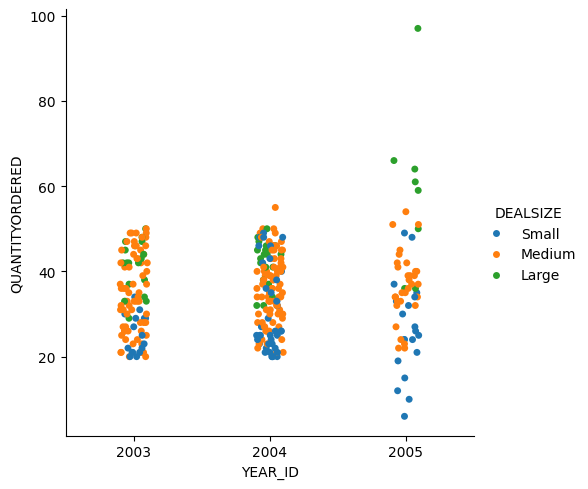

In [47]:
# BIEU DIENCATPLOT CUA QUANTITYORDERED THEO NHOM DEALSIZE 
sns.catplot(x='YEAR_ID',y='QUANTITYORDERED',hue='DEALSIZE',data=df) 
plt.show() 

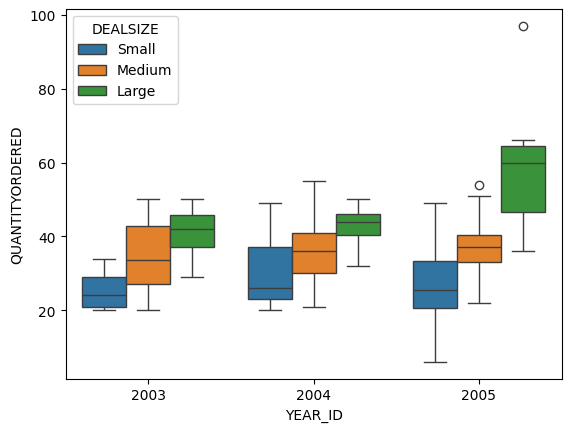

In [48]:
# BIEU DIEN BOXPLOT CUA QUANTITYORDERED THEO NAM,NHOM 
# DEALSIZE 
sns.boxplot(x='YEAR_ID',y='QUANTITYORDERED',hue='DEALSIZE',data=df) 
plt.show() 

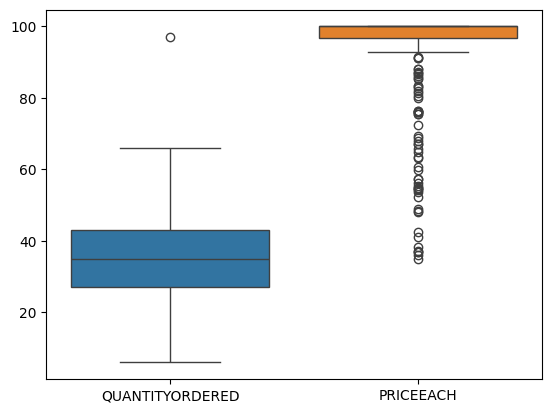

QUANTITYORDERED    0.708820
PRICEEACH         -2.424483
dtype: float64

In [49]:
#BIEU DIEN BOXPLOT CUA QUANTITYORDERED,PRICEEACH 
sns.boxplot(data=df[['QUANTITYORDERED','PRICEEACH']]) 
plt.show() 
#DO XIEN CUA PHAN PHOI (SKEW) CUA QUANTITYORDERED,PRICEEACH 
df[['QUANTITYORDERED','PRICEEACH']].skew() 

In [50]:
#DO NHON CUA PHAN PHOI (KURTORIS) CUA QUANTITYOREDERED , 
#PRICEEACH 
df[['QUANTITYORDERED','PRICEEACH']].kurtosis() 

QUANTITYORDERED    3.218123
PRICEEACH          4.959410
dtype: float64

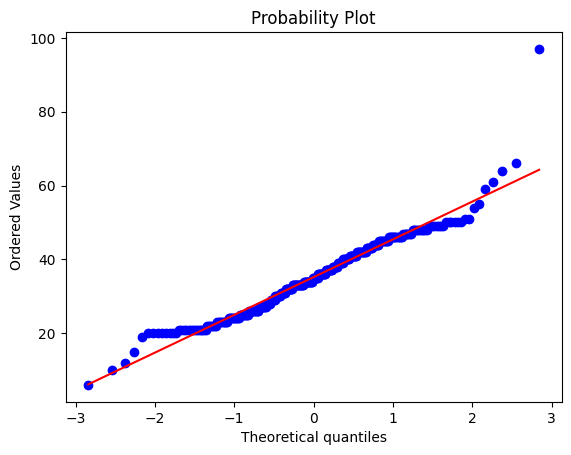

In [51]:
#KIEM TRA TINH CHUAN (NORMAL DISTRIBUTION) CUA 
#QUANTITYORDERED,PRICE,SALES 
from scipy import stats 
stats.probplot(df['QUANTITYORDERED'],plot=sns.mpl.pyplot) 
plt.show() 

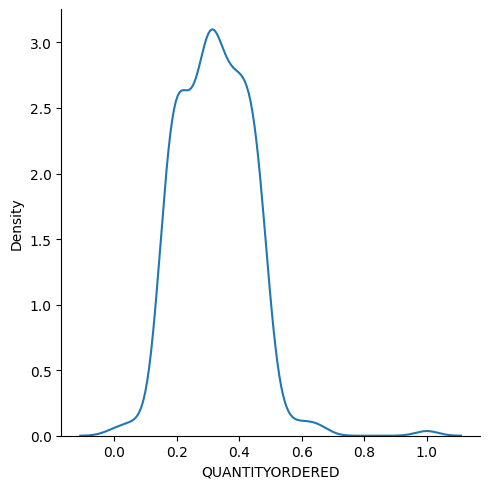

In [53]:
# THUC HIEN NORAMLIZE DU LIEU QUANTITYORDERED
from sklearn import preprocessing 
min_max_scaler=preprocessing.MinMaxScaler() 
df[['QUANTITYORDERED']]= min_max_scaler.fit_transform(df[['QUANTITYORDERED']]) 
sns.displot(df, x="QUANTITYORDERED", kind="kde") 
plt.show() 

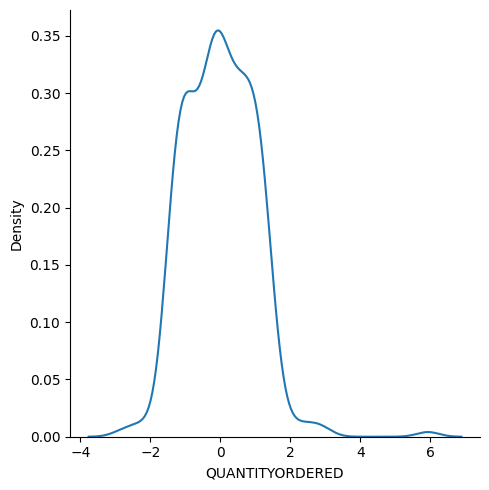

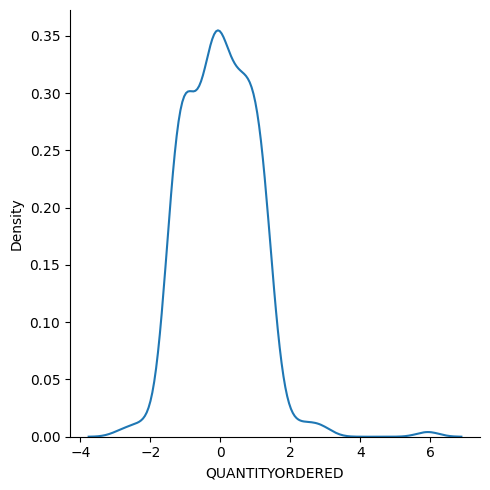

In [55]:
# THUC HIEN STANDARDIZATION DU LIEU QUANTITYORDERED  
from sklearn.preprocessing import StandardScaler 
scaler =StandardScaler() 
df[['QUANTITYORDERED']]=scaler.fit_transform(df[['QUANTITYORDERED']]) 
sns.displot(df,x="QUANTITYORDERED",kind="kde") 
plt.show() 
#c2 
from scipy import stats 
df['QUANTITYORDERED']=stats.zscore(df['QUANTITYORDERED']) 
stats.zscore(df['QUANTITYORDERED']) 
sns.displot(df,x="QUANTITYORDERED",kind="kde") 
plt.show()

In [56]:

# MA TRAN TUONG QUAN TUYEN TINH(PERSON) CUA CAC CAC 
# QUANTITYORDERED,PRICEEACH,SALES 
df[['QUANTITYORDERED','PRICEEACH','SALES']].corr() 
#hoat df[['QUANTITYORDERED','PRICEEACH','SALES']].cov() 

,QUANTITYORDERED,PRICEEACH,SALES
QUANTITYORDERED,1.000000,-0.002066,0.567122
PRICEEACH,-0.002066,1.000000,0.512066
SALES,0.567122,0.512066,1.000000


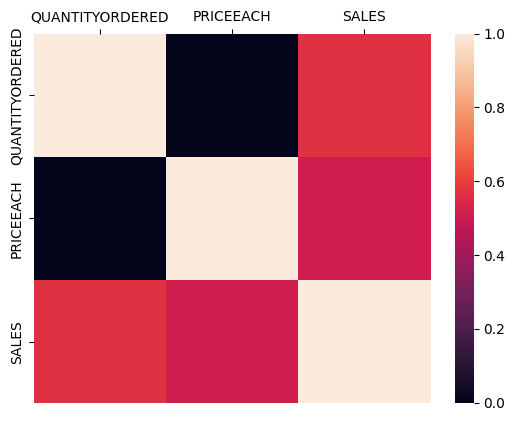

In [58]:
# VE BIEU DO HEATMAP TUONG QUAN GIUA CAC CAP 
# 'QUANTITYORDERED','PRICEEACH','SALES' 
sns.heatmap(df[['QUANTITYORDERED','PRICEEACH','SALES']].corr(),vmax=1.0,square=False).xaxis.tick_top() 

In [59]:
# TUONG QUAN CUA BIEN QUANTITYORDERED,PRICEEACH,SALES THEO 
# NHOM DEALSIZE 
df.groupby('DEALSIZE')[['QUANTITYORDERED','PRICEEACH','SALES']].corr() 

QUANTITYORDERED  PRICEEACH     SALES
DEALSIZE                                                      
Large    QUANTITYORDERED         1.000000  -0.701533  0.258853
         PRICEEACH              -0.701533   1.000000 -0.077445
         SALES                   0.258853  -0.077445  1.000000
Medium   QUANTITYORDERED         1.000000  -0.331658  0.397209
         PRICEEACH              -0.331658   1.000000  0.320828
         SALES                   0.397209   0.320828  1.000000
Small    QUANTITYORDERED         1.000000  -0.544644  0.294691
         PRICEEACH              -0.544644   1.000000  0.586297
         SALES                   0.294691   0.586297  1.000000

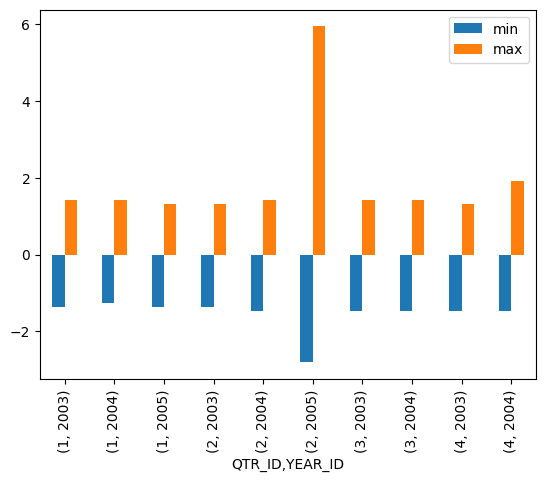

In [60]:
# VE BIEU DO CHO BIAET GIA TRI MIN ,MAX CUA SO LUONG SAN PHAM 
# TRONG MOI DON HANG THEO QUY,NAM 
gb=df.groupby(['QTR_ID','YEAR_ID'])['QUANTITYORDERED'].agg(['min','max']) 
gb.plot(kind='bar',stacked=False) 
plt.show() 

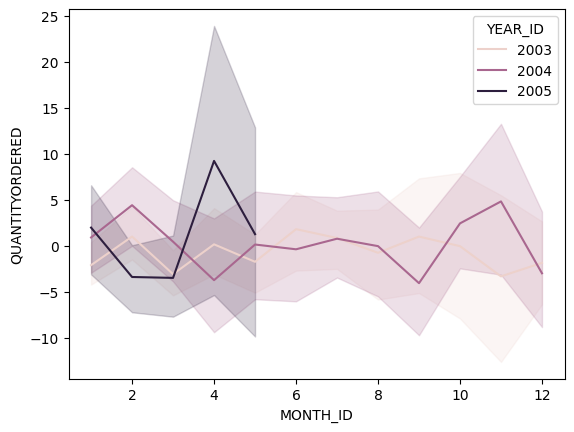

In [61]:
# VE BIEU DO CHO BIET TONG SO LUONG SAN PHAM THEO THANG 
sns.lineplot(x="MONTH_ID",y="QUANTITYORDERED",hue='YEAR_ID',data=df,estimator=sum) 
plt.show() 

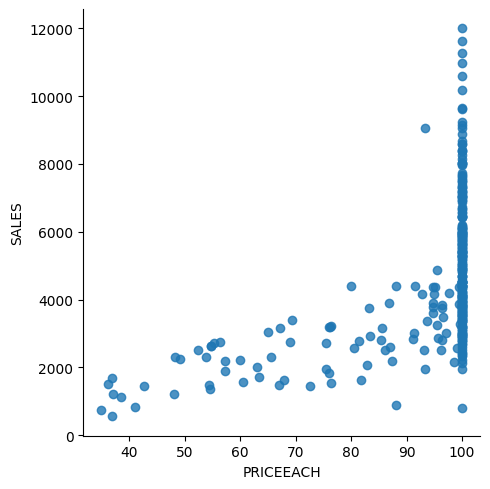

In [62]:
# VE BIEU DO CHO BIET QUAN HE GIUA SALES (Oy) VA DON GIA(Ox)// DUNG 
# BD SCATTER 
sns.lmplot(data=df,x='PRICEEACH',y='SALES',fit_reg=False) 
plt.show() 

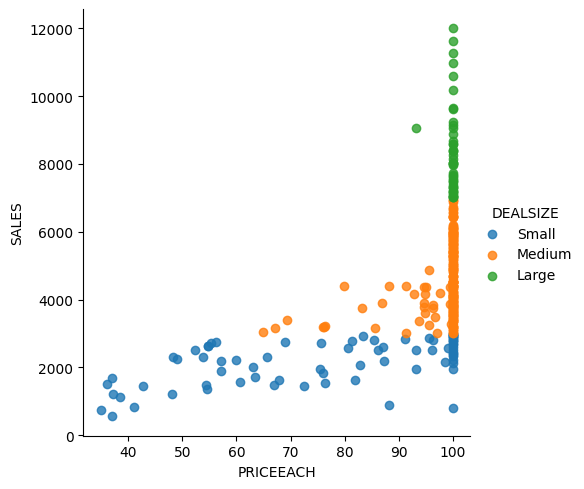

In [63]:
# VE BIEU DO CHO BIET QUAN HE GIUA SALES (Oy) VA DON GIA(Ox) THEO 
# DEALSIZE 
sns.lmplot(data=df,x='PRICEEACH',y='SALES',hue='DEALSIZE',fit_reg=False) 
plt.show() 

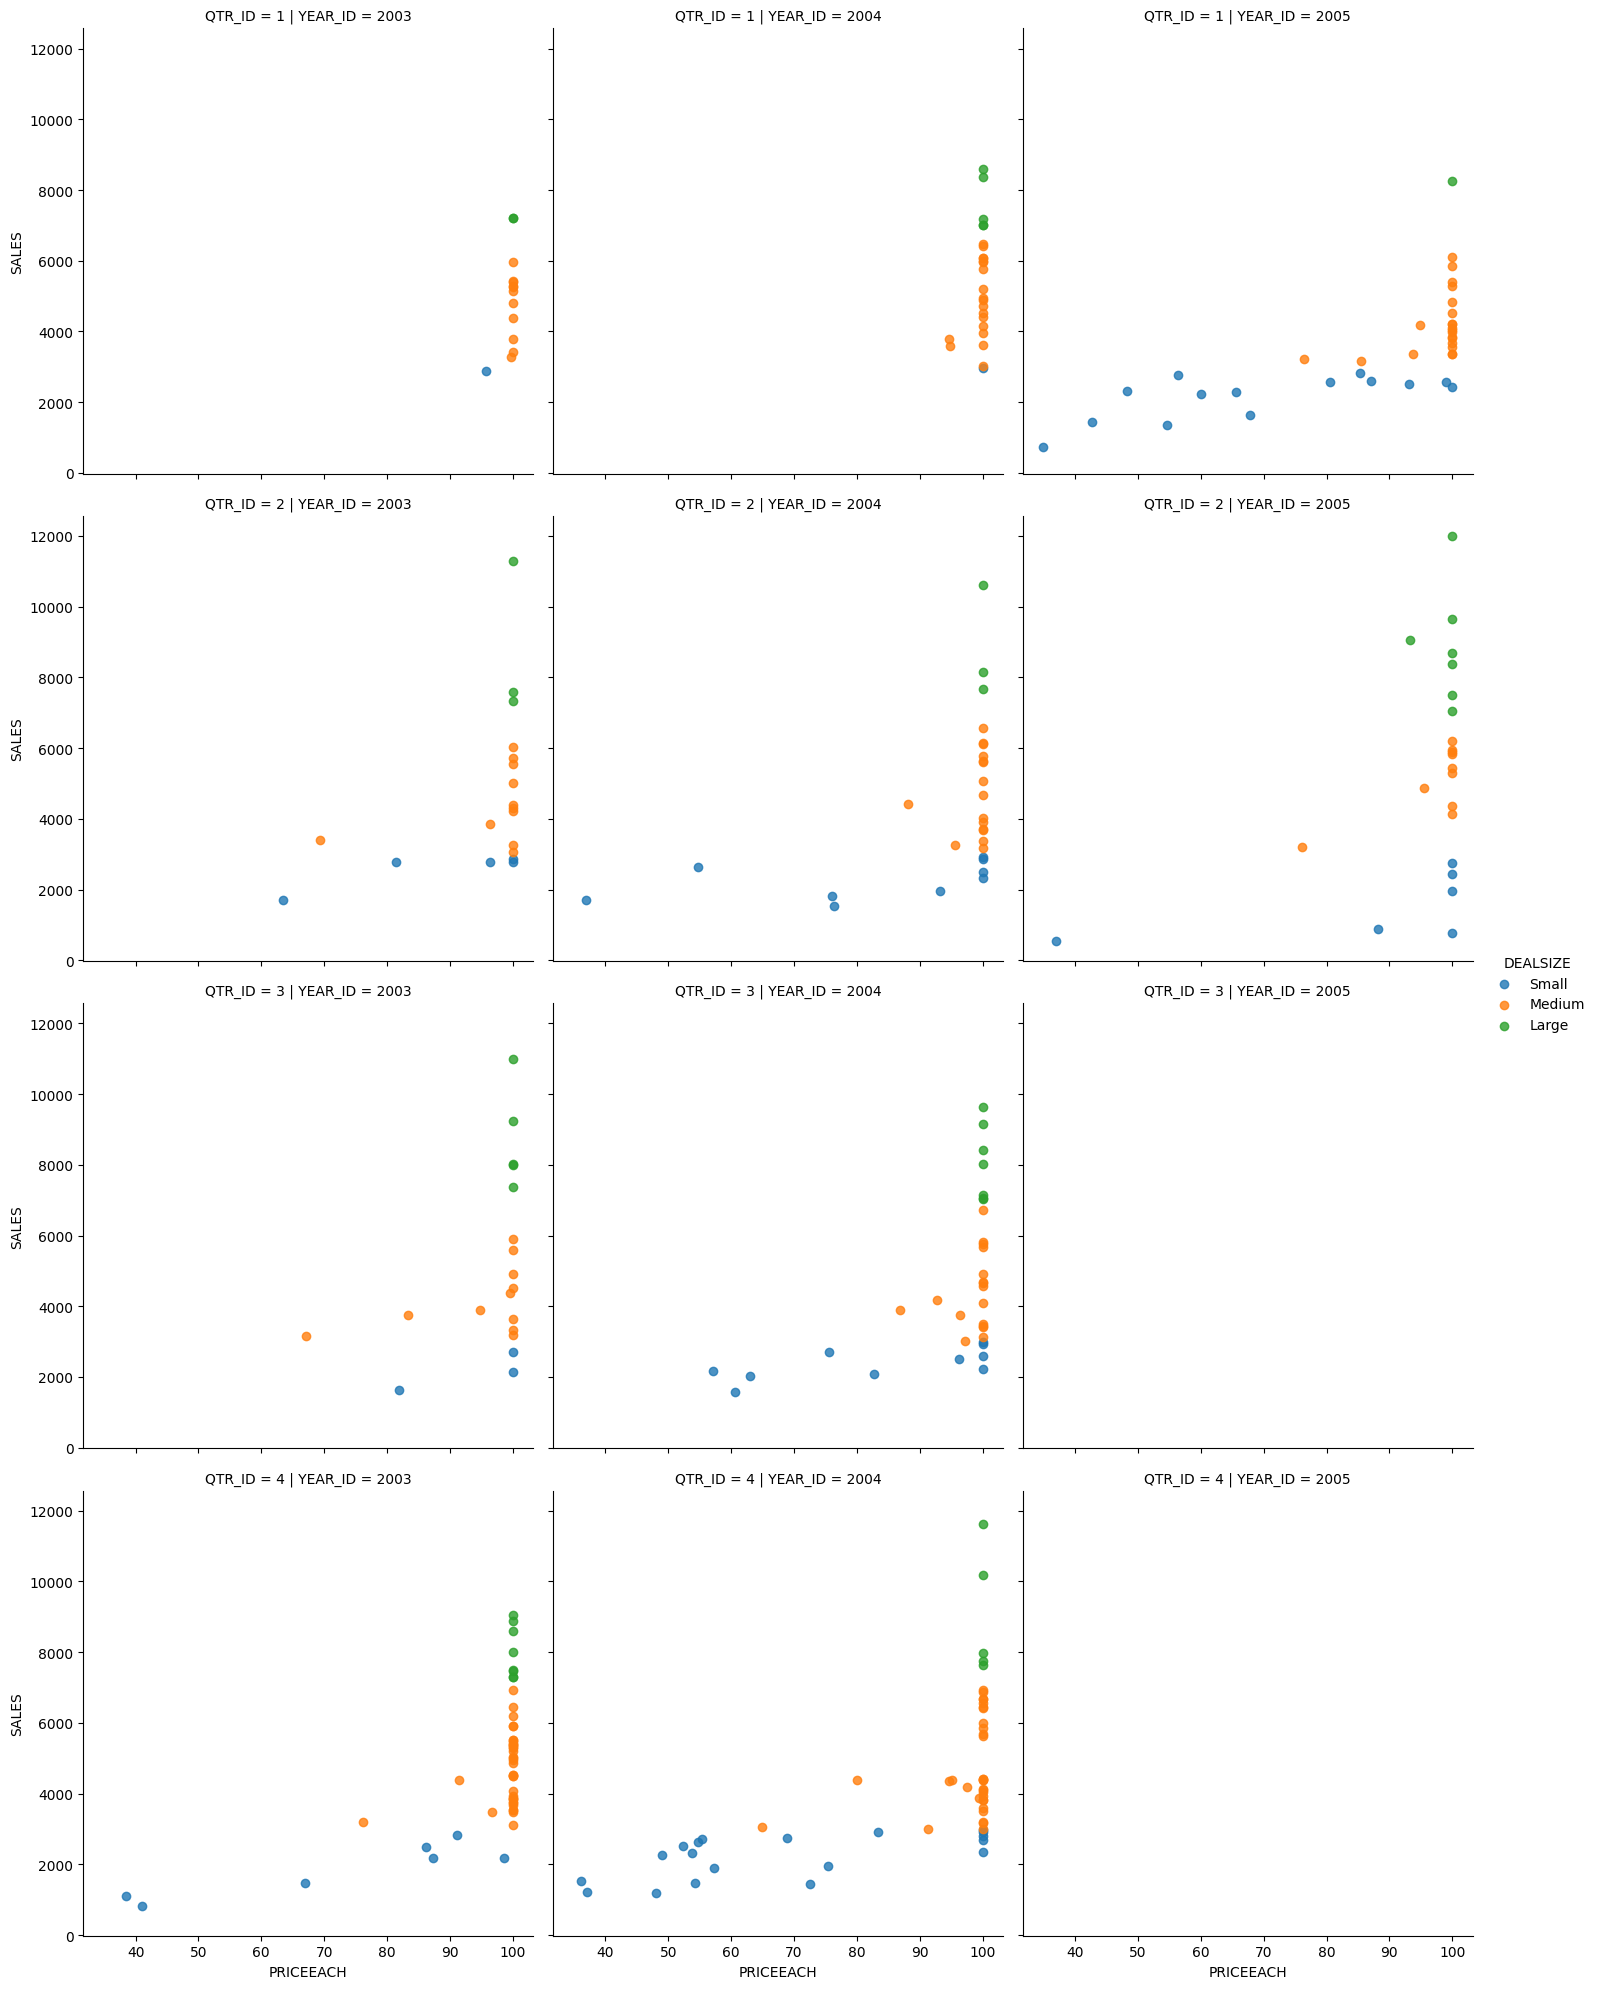

In [64]:
# VE BIEU DO CHO BIET QUAN HE GIUA SALES (Oy) VA DON GIA(Ox) THEO 
# DEALSIZE QUA CAC NAM (YEAR_ID) THEO COT VA THEO QUY QUA DONG 
sns.lmplot(data=df,x='PRICEEACH',y='SALES',hue='DEALSIZE',col='YEAR_ID',row=
 'QTR_ID',fit_reg=False) 
plt.show() 

In [65]:
#sap xep du lieu theo sales tang dan
df.sort_values(by='SALES',ascending=True) 

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTLASTNAME,PAYMENTFIRSTNAME
2044,10408,-1.940095,36.93,1,553.95,4/22/2005,Shipped,2,4,2005,...,Minato-ku,Tokyo,106-0032,Japan,Japan,Shimamura,Akiko,Small,Shimamura,Akiko
22,10375,-1.363978,34.91,12,733.11,2/3/2005,Shipped,1,2,2005,...,Nantes,Unknow,44000,France,EMEA,Labrune,Janine,Small,Labrune,Janine
751,10409,-2.804271,100.00,2,785.64,4/23/2005,Shipped,2,4,2005,...,Singapore,Unknow,69045,Singapore,APAC,Victorino,Wendy,Small,Victorino,Wendy
2356,10156,-1.459998,41.02,1,820.40,10/8/2003,Shipped,4,10,2003,...,Madrid,Unknow,28034,Spain,EMEA,Freyre,Diego,Small,Freyre,Diego
907,10423,-2.420193,88.14,1,881.40,5/30/2005,In Process,2,5,2005,...,Bruxelles,Unknow,B-1180,Belgium,EMEA,Dewey,Catherine,Small,Dewey,Catherine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,10247,0.844472,100.00,2,10606.20,5/5/2004,Shipped,2,5,2004,...,Espoo,Unknow,FIN-02271,Finland,EMEA,Suominen,Kalle,Large,Suominen,Kalle
30,10150,0.940491,100.00,8,10993.50,9/19/2003,Shipped,3,9,2003,...,Singapore,Unknow,79903,Singapore,Japan,Natividad,Eric,Large,Natividad,Eric
188,10127,1.036511,100.00,2,11279.20,6/3/2003,Shipped,2,6,2003,...,NYC,NY,10022,USA,Unknown,Young,Jeff,Large,Young,Jeff
44,10312,1.228550,100.00,3,11623.70,10/21/2004,Shipped,4,10,2004,...,San Rafael,CA,97562,USA,Unknown,Nelson,Valarie,Large,Nelson,Valarie


In [66]:
# Sap xep du lieu tang dan nhung khi trung lap se xet theo mua giam dan o cot khac
df.sort_values(by=['QUANTITYORDERED','PRICEEACH'],ascending=[True ,False]) 

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTLASTNAME,PAYMENTFIRSTNAME
751,10409,-2.804271,100.00,2,785.64,4/23/2005,Shipped,2,4,2005,...,Singapore,Unknow,69045,Singapore,APAC,Victorino,Wendy,Small,Victorino,Wendy
907,10423,-2.420193,88.14,1,881.40,5/30/2005,In Process,2,5,2005,...,Bruxelles,Unknow,B-1180,Belgium,EMEA,Dewey,Catherine,Small,Dewey,Catherine
185,10419,-2.228154,100.00,13,1961.28,5/17/2005,Shipped,2,5,2005,...,Salzburg,Unknow,5020,Austria,EMEA,Pipps,Georg,Small,Pipps,Georg
2044,10408,-1.940095,36.93,1,553.95,4/22/2005,Shipped,2,4,2005,...,Minato-ku,Tokyo,106-0032,Japan,Japan,Shimamura,Akiko,Small,Shimamura,Akiko
132,10414,-1.556017,100.00,3,2764.88,5/6/2005,On Hold,2,5,2005,...,Boston,MA,51003,USA,Unknown,Yoshido,Juri,Small,Yoshido,Juri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,10407,2.284765,100.00,11,7048.14,4/22/2005,On Hold,2,4,2005,...,San Jose,CA,94217,USA,Unknown,Frick,Sue,Large,Frick,Sue
473,10406,2.476804,100.00,3,8374.69,4/15/2005,Disputed,2,4,2005,...,Kobenhavn,Unknow,1734,Denmark,EMEA,Petersen,Jytte,Large,Petersen,Jytte
131,10400,2.764862,100.00,9,9661.44,4/1/2005,Shipped,2,4,2005,...,San Jose,CA,94217,USA,Unknown,Frick,Sue,Large,Frick,Sue
25,10417,2.956902,100.00,2,7516.08,5/13/2005,Disputed,2,5,2005,...,Madrid,Unknow,28034,Spain,EMEA,Freyre,Diego,Large,Freyre,Diego


In [67]:
# LỌC DATAFARME 
#Hiển thị các dòng có Sales>5000 
df[df['SALES']>5000] 
 
#Cách 2:  
df.loc[df['SALES']>5000]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTLASTNAME,PAYMENTFIRSTNAME
4,10159,1.324569,100.0,14,5205.27,10/10/2003,Shipped,4,10,2003,...,San Francisco,CA,0,USA,Unknown,Brown,Julie,Medium,Brown,Julie
7,10188,1.228550,100.0,1,5512.32,11/18/2003,Shipped,4,11,2003,...,Bergen,Unknow,N 5804,Norway,EMEA,Oeztan,Veysel,Medium,Oeztan,Veysel
20,10341,0.556413,100.0,9,7737.93,11/24/2004,Shipped,4,11,2004,...,Salzburg,Unknow,5020,Austria,EMEA,Pipps,Georg,Large,Pipps,Georg
25,10417,2.956902,100.0,2,7516.08,5/13/2005,Disputed,2,5,2005,...,Madrid,Unknow,28034,Spain,EMEA,Freyre,Diego,Large,Freyre,Diego
26,10103,-0.883880,100.0,11,5404.62,1/29/2003,Shipped,1,1,2003,...,Stavern,Unknow,4110,Norway,EMEA,Bergulfsen,Jonas,Medium,Bergulfsen,Jonas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,10421,-0.019704,100.0,1,5433.75,5/29/2005,In Process,2,5,2005,...,San Rafael,CA,97562,USA,Unknown,Nelson,Valarie,Medium,Nelson,Valarie
990,10128,0.556413,100.0,2,5544.02,6/6/2003,Shipped,2,6,2003,...,Madrid,Unknow,28034,Spain,EMEA,Freyre,Diego,Medium,Freyre,Diego
993,10166,0.748452,100.0,2,6930.74,10/21/2003,Shipped,4,10,2003,...,New Bedford,MA,50553,USA,Unknown,Benitez,Violeta,Medium,Benitez,Violeta
1226,10249,1.036511,100.0,5,5600.50,5/8/2004,Shipped,2,5,2004,...,Cambridge,MA,51247,USA,Unknown,Tseng,Kyung,Medium,Tseng,Kyung


In [69]:
# ĐIỀU KIỆN GỘP 
#Hiển thị các dòng có Sales>5000 và QuantityOrdered>40 
df[(df['SALES']>5000) &(df['QUANTITYORDERED']>4)]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTLASTNAME,PAYMENTFIRSTNAME
418,10405,5.933507,93.28,5,9048.16,4/14/2005,Shipped,2,4,2005,...,Strasbourg,Unknow,67000,France,EMEA,Citeaux,Frederique,Large,Citeaux,Frederique


In [70]:
# TẠO CỘT MỚI VÀ GÁN THUỘC TÍNH MỚI TRÊN BẢNG 
#Lọc ra các dòng có Priceeach<65, nếu có thay giá trị bằng Cheap, ngược lại thay bằng 
# Expensive 
df.loc[df['PRICEEACH']<65,'FLAG']='CHEAP' 
df.loc[df['PRICEEACH']>=65,'FLAG']='EXPENSIVE' 
df[['PRICEEACH','FLAG']] 

,PRICEEACH,FLAG
0,95.70,EXPENSIVE
1,81.35,EXPENSIVE
2,94.74,EXPENSIVE
3,83.26,EXPENSIVE
4,100.00,EXPENSIVE
...,...,...
2358,38.40,CHEAP
2532,80.55,EXPENSIVE
2554,100.00,EXPENSIVE
2692,100.00,EXPENSIVE


In [71]:
#Viết hàm foo(x) nếu x<10 trả về Bad, nếu x>=10 và <50 trả về Good, ngược lại trả về 
# Excellent 
def foo(x): 
    if x < 10 :  
        return 'BAD' 
    elif x >= 10 and x < 50: 
            return 'GODD' 
    else: 
                return 'EXCELLENT' 
#Áp dụng cho cột month 
df['MONTH']= df[['QUANTITYORDERED']].applymap(foo) 
#Hiển thị kết quả 
df[['QUANTITYORDERED','MONTH']] 

C:\Users\Admin\AppData\Local\Temp\ipykernel_4652\4165098326.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df['MONTH']= df[['QUANTITYORDERED']].applymap(foo)


,QUANTITYORDERED,MONTH
0,-0.499802,BAD
1,-0.115724,BAD
2,0.556413,BAD
3,0.940491,BAD
4,1.324569,BAD
...,...,...
2358,-0.595822,BAD
2532,-0.307763,BAD
2554,-1.171939,BAD
2692,0.076315,BAD


In [74]:
# SO SÁNH CỘT 
#Viết hàm so sánh giá trị nếu x<=y trả về giá trị YES, ngược lại là NO 
def ftrust(x,y): 
    if x<=y: 
        return 'YES' 
    else: 
        return'NO' 
#Áp dụng hàm để gán giá trị trả về cho TRUST         
df['TRUST']=list(map(ftrust, df['PRICEEACH'],df['MSRP'])) 

 #Hiển thị kết quả sau khi gọi hàm 
df[['PRICEEACH','MSRP','TRUST']] 
 
#Thay đổi giá trị cho cột QTR_ID là Q1 nếu giá trị là 1, Q2 nếu giá trị là 2,... 
dict_map= {1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'} 
df['QTR_ID']= df['QTR_ID'].map(dict_map)


In [75]:
 
# XÁC ĐỊNH CÁC HÀM TỔNG HỢP TRÊN CÁC BIẾN ĐỊNH LƯỢNG VÀ ĐỊNH 
# TÍNH 
#Hiển thị giá trị tổng , giá trị nhỏ nhất cho cột QUANTITYORDERED, giá trị nhỏ nhất 
# và lớn nhất và trung bình cho cột PRICEEACH, giá trị nhỏ nhất và trung bình cho cột 
# SALES 
df.aggregate({'QUANTITYORDERED':['sum','min'],'PRICEEACH':['min', 'max', 
'mean'],'SALES':['min','mean']})

,QUANTITYORDERED,PRICEEACH,SALES
sum,1.776357e-15,NaN,NaN
min,-2.804271e+00,34.910000,553.950000
max,NaN,100.000000,NaN
mean,NaN,93.351596,4588.486906


In [76]:
# GROUP BY: NHÓM 
#Hiển thị giá trị tổng , giá trị nhỏ nhất cho cột QUANTITYORDERED, giá trị nhỏ nhất 
# và lớn nhất và trung bình cho cột PRICEEACH, giá trị nhỏ nhất và trung bình cho cột 
# SALES 
df.aggregate({'QUANTITYORDERED':['sum','min'],'PRICEEACH':['min', 'max', 
'mean'],'SALES':['min','mean']})

,QUANTITYORDERED,PRICEEACH,SALES
sum,1.776357e-15,NaN,NaN
min,-2.804271e+00,34.910000,553.950000
max,NaN,100.000000,NaN
mean,NaN,93.351596,4588.486906


In [77]:
#Thống kê tổng, trung vị, độ lệnh chuẩn của SALES theo từng nhóm DEALSIZE 
df.groupby(['DEALSIZE'])['SALES'].agg(['sum','mean','std']) 

,sum,mean,std
DEALSIZE,,,
Large,385225.84,8374.474783,1311.082806
Medium,858879.42,4617.631290,1060.525537
Small,164560.22,2194.136267,640.637657


In [79]:
#Thống kê tổng, trung vị, độ lệnh chuẩn của SALES theo từng nhóm DEALSIZE, cùng 
# DEALSIZE thì nhóm theo QTR_ID 
df.groupby(['DEALSIZE','QTR_ID'])['SALES'].agg(['sum','mean','std'])

,,sum,mean,std
DEALSIZE,QTR_ID,,,


In [80]:
# XUẤT BẢNG TÍNH THEO THUỘC TÍNH CỦA BẢNG 
pd.pivot_table(df,values='SALES',columns='YEAR_ID',aggfunc=['sum','mean'])

sum                               mean               \
YEAR_ID       2003       2004       2005         2003         2004   
SALES    504289.01  654842.91  249533.56  4848.932788  4547.520208   

                      
YEAR_ID         2005  
SALES    4229.382373

In [81]:
#Thống kê theo dạng bảng Pivot 2 chiều: Thống kê tổng và trung bình số lượng 
# QUANTITYORDERED và SALES theo Year_ID 
pd.pivot_table(df,values=['SALES','QUANTITYORDERED'],columns='YEAR_ID',aggfunc=['sum','mean'])

sum                                      mean  \
YEAR_ID                   2003          2004           2005         2003   
QUANTITYORDERED      -8.194502       2.63569       5.558812    -0.078793   
SALES            504289.010000  654842.91000  249533.560000  4848.932788   

                                           
YEAR_ID                 2004         2005  
QUANTITYORDERED     0.018303     0.094217  
SALES            4547.520208  4229.382373